# ch308 — Initialisation Strategies

## 1. Why initialisation matters

Backpropagation propagates gradients multiplicatively through $L$ layers.
If weights are too large, activations and gradients explode. Too small, they vanish.
Both pathologies kill learning *(ch306, vanishing/exploding gradients)*.

The goal of initialisation is to set initial weights such that the **variance of
activations and gradients is approximately preserved across layers** at the start of training.

---

## 2. The variance propagation analysis

For a linear layer $z = Wx$ with $n_{in}$ inputs, $n_{out}$ outputs, and $x \sim \mathcal{N}(0, 1)$:

$$\text{Var}(z_i) = n_{in} \cdot \text{Var}(W_{ij}) \cdot \text{Var}(x_j)$$

To keep $\text{Var}(z) = \text{Var}(x)$, we need $\text{Var}(W) = 1/n_{in}$.

During backprop, the same analysis applies to gradients flowing backward, requiring
$\text{Var}(W) = 1/n_{out}$.

**Xavier (Glorot) initialisation** compromises between forward and backward:
$$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$$

*(Variance and distributions: ch250, ch253.)*

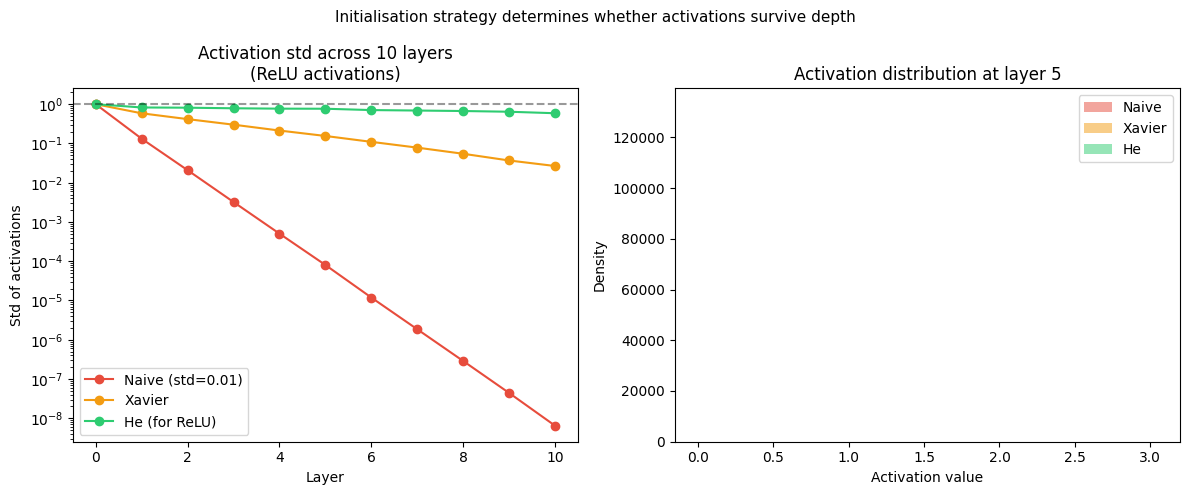

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def xavier_init(fan_in, fan_out, rng):
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return rng.uniform(-limit, limit, (fan_out, fan_in))

def he_init(fan_in, fan_out, rng):
    """He (Kaiming) initialisation for ReLU networks."""
    std = np.sqrt(2.0 / fan_in)
    return rng.normal(0, std, (fan_out, fan_in))

def naive_init(fan_in, fan_out, rng):
    return rng.normal(0, 0.01, (fan_out, fan_in))


def simulate_forward_variance(init_fn, layer_sizes, n_samples=1000, seed=0):
    """Track activation std across layers."""
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, (layer_sizes[0], n_samples))
    stds = [x.std()]
    for i in range(len(layer_sizes) - 1):
        W = init_fn(layer_sizes[i], layer_sizes[i+1], rng)
        x = np.maximum(0, W @ x)  # ReLU
        stds.append(x.std())
    return stds


layer_sizes = [512] * 11  # 10 hidden layers

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for init_fn, name, color in [
    (naive_init, 'Naive (std=0.01)', '#e74c3c'),
    (xavier_init, 'Xavier', '#f39c12'),
    (he_init, 'He (for ReLU)', '#2ecc71'),
]:
    stds = simulate_forward_variance(init_fn, layer_sizes)
    axes[0].plot(stds, marker='o', color=color, label=name)

axes[0].set_title('Activation std across 10 layers\n(ReLU activations)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Std of activations')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.4, label='Target std=1')

# Distribution of activations at layer 5
for init_fn, name, color in [
    (naive_init, 'Naive', '#e74c3c'),
    (xavier_init, 'Xavier', '#f39c12'),
    (he_init, 'He', '#2ecc71'),
]:
    rng = np.random.default_rng(0)
    x = rng.normal(0, 1, (512, 500))
    for i in range(5):
        W = init_fn(512, 512, rng)
        x = np.maximum(0, W @ x)
    axes[1].hist(x.ravel()[:3000], bins=60, alpha=0.5, color=color, label=name, density=True)

axes[1].set_title('Activation distribution at layer 5')
axes[1].set_xlabel('Activation value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Initialisation strategy determines whether activations survive depth', fontsize=11)
plt.tight_layout()
plt.savefig('ch308_init.png', dpi=120)
plt.show()

## 3. He initialisation for ReLU

Xavier assumes symmetric activations. ReLU kills half the variance (negative half → 0).
**He (Kaiming) initialisation** corrects for this:

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

The factor of 2 compensates for the expected 50% dead neurons at each layer.

Use Xavier for Tanh/Sigmoid activations. Use He for ReLU and its variants.

---

## 4. Orthogonal initialisation

For very deep networks, random initialisation can still cause issues. **Orthogonal initialisation**
sets $W$ to a random orthogonal matrix (via QR decomposition of a random Gaussian matrix).
Orthogonal matrices preserve vector norms exactly: $\|Wx\| = \|x\|$.

This guarantees neither explosion nor vanishing at initialisation, but requires the matrix
to be square — impractical for arbitrary layer sizes. Used in RNNs *(ch317)*.

---

## 5. Bias initialisation

Biases are almost always initialised to zero. The exception: output layer biases can be
set to $\log(p/(1-p))$ where $p$ is the base rate of the positive class — this speeds
up early convergence for imbalanced datasets.

---

## 6. Summary

- Variance must be preserved across layers: too large = explosion, too small = vanishing.
- Xavier: correct for tanh/sigmoid. He: correct for ReLU (factor of 2 for killed half).
- Bias initialisation: zero, unless you have domain knowledge about base rates.
- Orthogonal init: useful for RNNs and very deep networks.

---

## 7. Forward and backward references

**Used here:** variance *(ch250)*, normal distribution *(ch253)*, chain rule through layers *(ch306)*.

**This will reappear in ch310 — Batch Normalisation**, which eliminates much of the
sensitivity to initialisation by normalising activations during training.